# **Predict Medical Insurance Costs**

We will build a model to `Predict Medical Insurance Costs` based on a patient's age, BMI, smoking habits, and other factors.

In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.shape

(1338, 7)

In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [7]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.describe(include = 'string')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

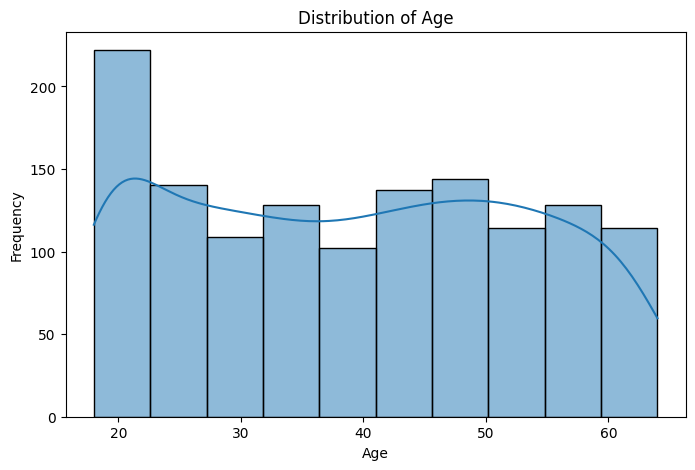

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=10, kde = True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

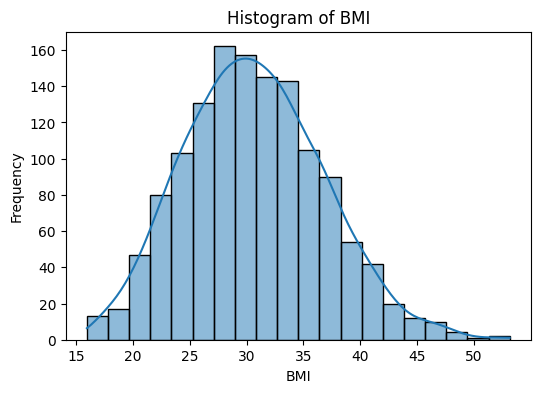

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["bmi"], bins=20, kde = True)
plt.title("Histogram of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

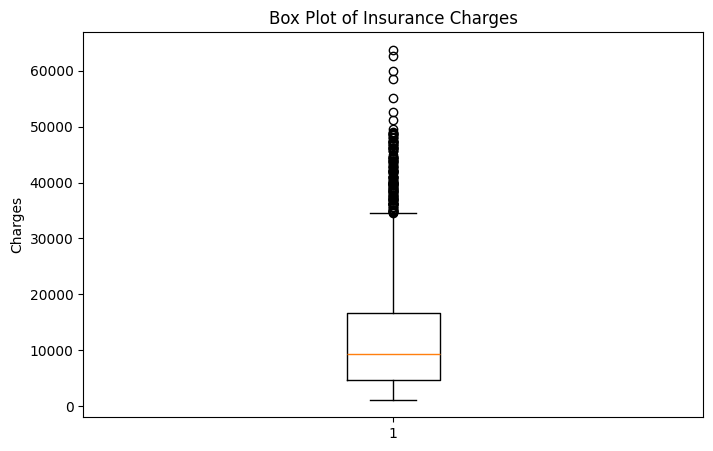

In [13]:
plt.figure(figsize=(8,5))
plt.boxplot(df["charges"])
plt.title("Box Plot of Insurance Charges")
plt.ylabel("Charges")
plt.show()

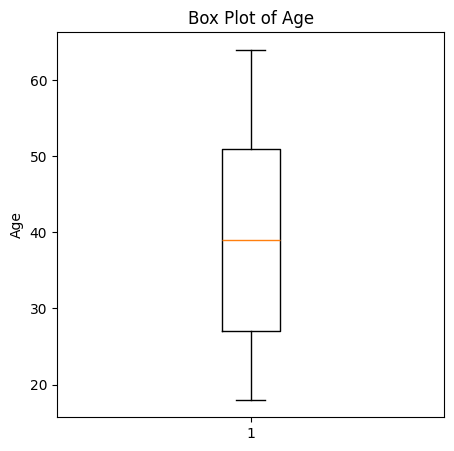

In [14]:
plt.figure(figsize=(5,5))
plt.boxplot(df["age"])
plt.title("Box Plot of Age")
plt.ylabel("Age")
plt.show()

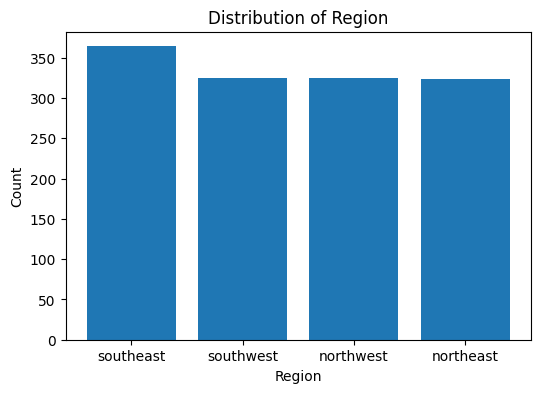

In [15]:
region_counts = df["region"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(region_counts.index, region_counts.values)
plt.title("Distribution of Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

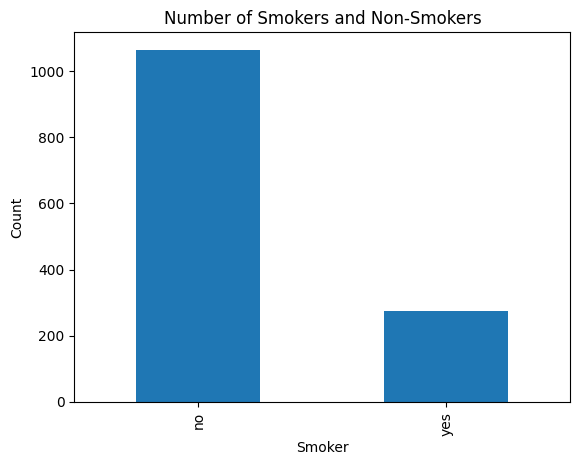

In [16]:
df["smoker"].value_counts().plot(kind="bar")
plt.title("Number of Smokers and Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.show() 

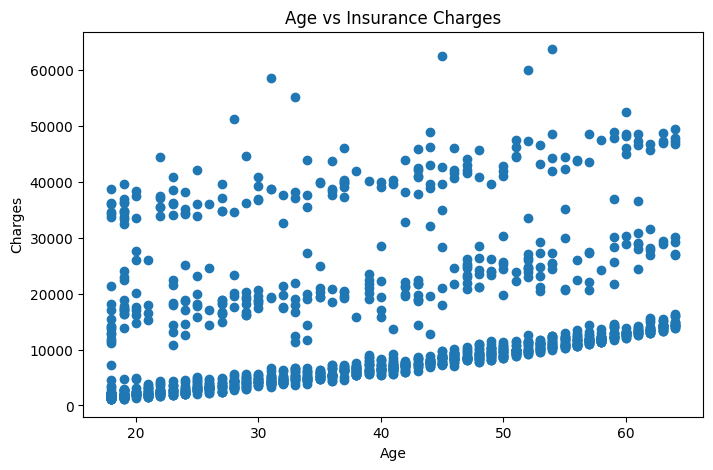

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["charges"])
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show() 

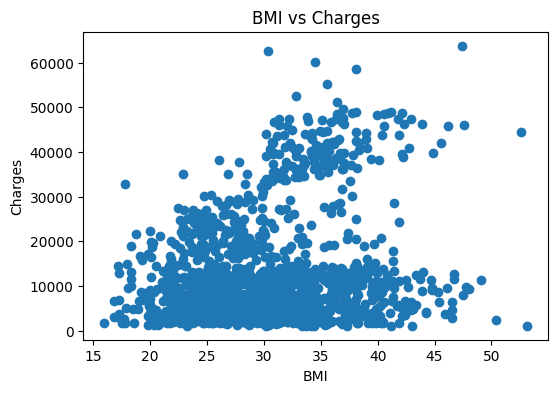

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(df["bmi"], df["charges"])
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

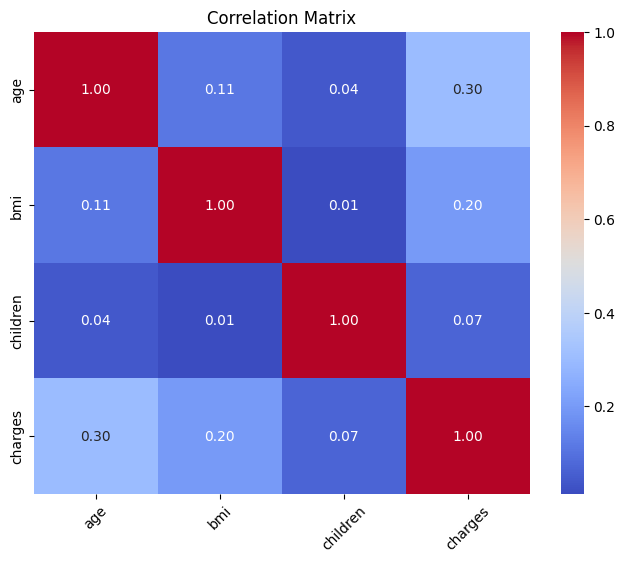

In [19]:
# Select only numerical columns
corr = df.corr(numeric_only=True)
# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.xticks(rotation=45)
plt.title("Correlation Matrix")
plt.show()

In [20]:
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


In [21]:
# numerical feature has the strongest correlation with charges
corr = df.corr(numeric_only=True)
print(corr["charges"].sort_values(ascending=False))

charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [23]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(1)

In [25]:
df['smoker'].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [26]:
df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [27]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [28]:
df[['age', 'bmi', 'charges']].describe()

,age,bmi,charges
count,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,13270.422265
std,14.049960,6.098187,12110.011237
min,18.000000,15.960000,1121.873900
25%,27.000000,26.296250,4740.287150
50%,39.000000,30.400000,9382.033000
75%,51.000000,34.693750,16639.912515
max,64.000000,53.130000,63770.428010


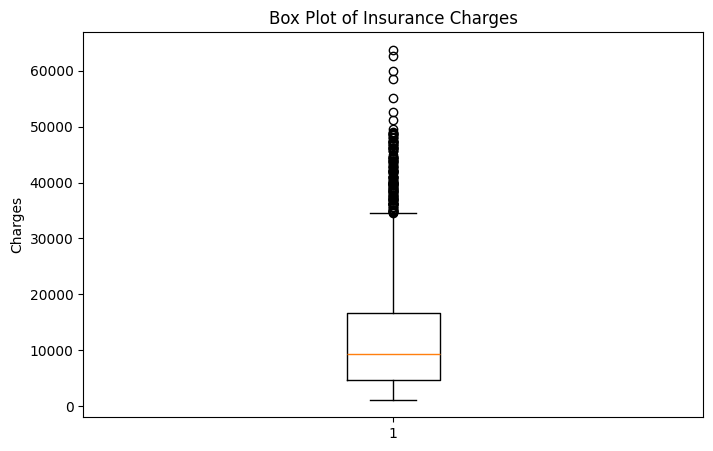

In [29]:
plt.figure(figsize=(8,5))
plt.boxplot(df["charges"])
plt.title("Box Plot of Insurance Charges")
plt.ylabel("Charges")
plt.show() 

In [30]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["charges"] < lower) | (df["charges"] > upper)]
print(outliers.sort_values('charges', ascending = True))

      age     sex     bmi  children smoker     region      charges
623    18    male  33.535         0    yes  northeast  34617.84065
1078   28    male  31.680         0    yes  southeast  34672.14720
223    19    male  34.800         0    yes  southwest  34779.61500
689    27    male  31.130         1    yes  southeast  34806.46770
1291   19    male  34.900         0    yes  southwest  34828.65400
...   ...     ...     ...       ...    ...        ...          ...
819    33  female  35.530         0    yes  northwest  55135.40209
577    31  female  38.095         1    yes  northeast  58571.07448
1230   52    male  34.485         3    yes  northwest  60021.39897
1300   45    male  30.360         0    yes  southeast  62592.87309
543    54  female  47.410         0    yes  southeast  63770.42801

[139 rows x 7 columns]


In [31]:
from scipy.stats import zscore 
df['zscore'] = zscore(df['charges']) 
outliers = df[df['zscore'].abs() > 3]
outliers.sort_values('charges', ascending = True)

,age,sex,bmi,children,smoker,region,charges,zscore
34,28,male,36.400,1,yes,southwest,51194.55914,3.132806
1146,60,male,32.800,0,yes,southwest,52590.82939,3.248148
819,33,female,35.530,0,yes,northwest,55135.40209,3.458348
577,31,female,38.095,1,yes,northeast,58571.07448,3.742159
1230,52,male,34.485,3,yes,northwest,60021.39897,3.861966
1300,45,male,30.360,0,yes,southeast,62592.87309,4.074389
543,54,female,47.410,0,yes,southeast,63770.42801,4.171663


In [32]:
df = df.drop('zscore', axis = 1)

In [33]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["smoker"] = encoder.fit_transform(df["smoker"])

In [34]:
encoded_df = pd.get_dummies(df, columns = ['region'], drop_first = True) 

In [35]:
df = encoded_df

In [36]:
encoder = LabelEncoder()
df["sex"] = encoder.fit_transform(df["sex"])

In [37]:
df.sample(10)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
739,29,1,35.500,2,1,44585.45587,False,False,True
438,52,0,46.750,5,0,12592.53450,False,True,False
770,61,1,36.100,3,0,27941.28758,False,False,True
519,31,1,30.875,0,0,3857.75925,False,False,False
1299,19,0,25.745,1,0,2710.82855,True,False,False
150,35,1,24.130,1,0,5125.21570,True,False,False
68,40,0,36.190,0,0,5920.10410,False,True,False
874,44,1,21.850,3,0,8891.13950,False,False,False
34,28,1,36.400,1,1,51194.55914,False,False,True
491,61,0,25.080,0,0,24513.09126,False,True,False


In [38]:
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler() 
scaled_data = scaler.fit_transform(df[['age', 'bmi', 'children']])
normalized_df = pd.DataFrame(scaled_data, columns = ['age', 'bmi', 'children'])

In [39]:
normalized_df.head()

,age,bmi,children
0,0.021739,0.321227,0.0
1,0.000000,0.479150,0.2
2,0.217391,0.458434,0.6
3,0.326087,0.181464,0.0
4,0.304348,0.347592,0.0


In [40]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
scaled_data = scaler.fit_transform(df[['age', 'bmi', 'children']])
standardized_df = pd.DataFrame(scaled_data, columns = ['age', 'bmi', 'children'])

In [41]:
standardized_df.head()

,age,bmi,children
0,-1.438764,-0.453320,-0.908614
1,-1.509965,0.509621,-0.078767
2,-0.797954,0.383307,1.580926
3,-0.441948,-1.305531,-0.908614
4,-0.513149,-0.292556,-0.908614


In [42]:
print("Min-Max Scaling")
print(normalized_df.head())

print("\nStandardization")
print(standardized_df.head())

Min-Max Scaling
        age       bmi  children
0  0.021739  0.321227       0.0
1  0.000000  0.479150       0.2
2  0.217391  0.458434       0.6
3  0.326087  0.181464       0.0
4  0.304348  0.347592       0.0

Standardization
        age       bmi  children
0 -1.438764 -0.453320 -0.908614
1 -1.509965  0.509621 -0.078767
2 -0.797954  0.383307  1.580926
3 -0.441948 -1.305531 -0.908614
4 -0.513149 -0.292556 -0.908614


In [43]:
from sklearn.model_selection import train_test_split 

X = df[["age", "bmi", "children"]]
y = df['charges'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [44]:
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler() 
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = scaler.transform(X_test) 

In [45]:
print(X_train_minmax[:5])

[[0.60869565 0.10734463 0.4       ]
 [0.63043478 0.22491256 0.        ]
 [0.73913043 0.23944041 0.        ]
 [0.45652174 0.49394673 1.        ]
 [0.7826087  0.14823783 0.6       ]]


In [46]:
print(X_test_minmax[:5])

[[0.58695652 0.24791499 0.4       ]
 [0.39130435 0.37826204 0.        ]
 [1.         0.29391983 0.        ]
 [0.60869565 0.26324993 0.6       ]
 [0.02173913 0.42937853 0.        ]]


In [47]:
print("Training Min:", scaler.data_min_)
print("Training Max:", scaler.data_max_)

# Notice we use transform(), not fit_transform()
X_test_minmax = scaler.transform(X_test)

Training Min: [18.   15.96  0.  ]
Training Max: [64.   53.13  5.  ]


In [48]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

X_train_std = standard.fit_transform(X_train)
X_test_std = standard.transform(X_test)

In [49]:
print("Min-Max Scaled")
print(pd.DataFrame(X_train_minmax, columns=X.columns).describe())

print("\nStandardized")
print(pd.DataFrame(X_train_std, columns=X.columns).describe())

Min-Max Scaled
               age          bmi     children
count  1070.000000  1070.000000  1070.000000
mean      0.464283     0.392801     0.221495
std       0.305956     0.162588     0.243197
min       0.000000     0.000000     0.000000
25%       0.195652     0.275626     0.000000
50%       0.467391     0.383374     0.200000
75%       0.717391     0.498688     0.400000
max       1.000000     1.000000     1.000000

Standardized
                age           bmi      children
count  1.070000e+03  1.070000e+03  1.070000e+03
mean  -1.992176e-16 -4.648410e-17 -2.324205e-17
std    1.000468e+00  1.000468e+00  1.000468e+00
min   -1.518194e+00 -2.417060e+00 -9.111921e-01
25%   -8.784157e-01 -7.210253e-01 -9.111921e-01
50%    1.016470e-02 -5.800739e-02 -8.842793e-02
75%    8.276587e-01  6.515707e-01  7.343363e-01
max    1.751782e+00  3.736342e+00  3.202629e+00


In [50]:
from sklearn.model_selection import train_test_split 

# Separate features and target 
X = df.drop('charges', axis = 1) 
y = df['charges'] 

# Split the dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [51]:
print("X - Train Shape: ", X_train.shape) 
print("X - Test Shape: ", X_test.shape)
print("y - Train Shape: ", y_train.shape)
print("y - Test Shape: ", y_test.shape)

X - Train Shape:  (1070, 8)
X - Test Shape:  (268, 8)
y - Train Shape:  (1070,)
y - Test Shape:  (268,)


In [52]:
X_train.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
560,46,0,19.95,2,0,True,False,False
1285,47,0,24.32,0,0,False,False,False
1142,52,0,24.86,0,0,False,True,False
969,39,0,34.32,5,0,False,True,False
486,54,0,21.47,3,0,True,False,False


In [53]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.20, random_state=10)

In [54]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression() 
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
model.intercept_

np.float64(-11931.21905032667)

In [56]:
model.coef_

array([ 2.56975706e+02, -1.85916916e+01,  3.37092552e+02,  4.25278784e+02,
        2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02])

In [57]:
y_pred = model.predict(X_test)

In [58]:
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"{feature}: {coef}")

age: 256.9757058311942
sex: -18.591691641035993
bmi: 337.0925519487791
children: 425.2787835242934
smoker: 23651.128855761253
region_northwest: -370.6773262277898
region_southeast: -657.8642965646405
region_southwest: -809.7993541824902


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [60]:
mae = mean_absolute_error(y_test, y_pred) 
mse = mean_squared_error(y_test, y_pred) 
rmse = np.sqrt(mse) 
r2 = r2_score(y_test, y_pred)

In [61]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 4181.194473753647
MSE : 33596915.851361446
RMSE: 5796.284659276272
R²  : 0.7835929767120724


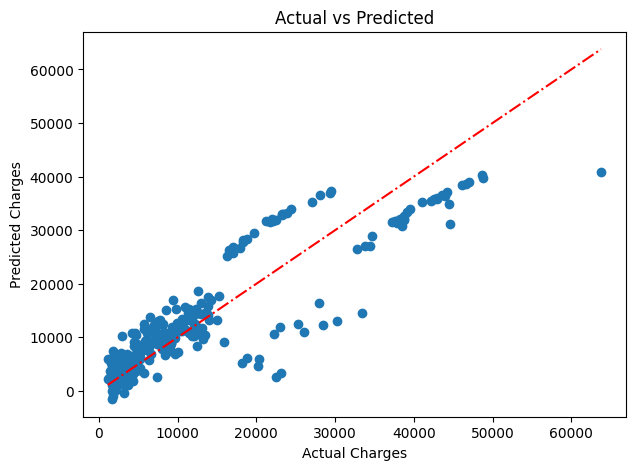

In [62]:
plt.figure(figsize = (7, 5)) 
plt.scatter(y_test, y_pred) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', linestyle = '-.')
plt.xlabel("Actual Charges") 
plt.ylabel("Predicted Charges") 
plt.title("Actual vs Predicted")
plt.show() 

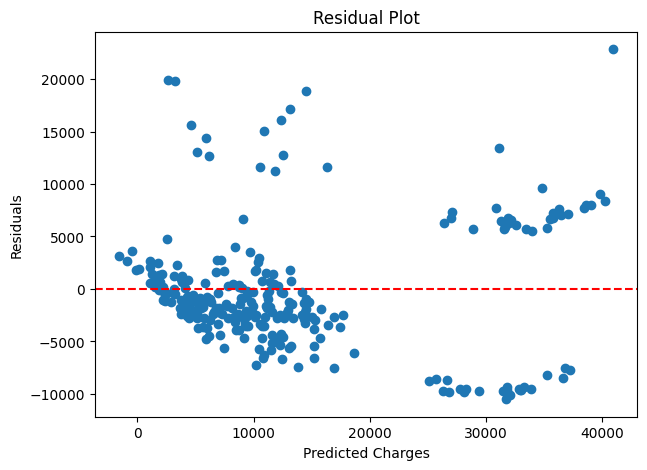

In [63]:
residuals = y_test - y_pred
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

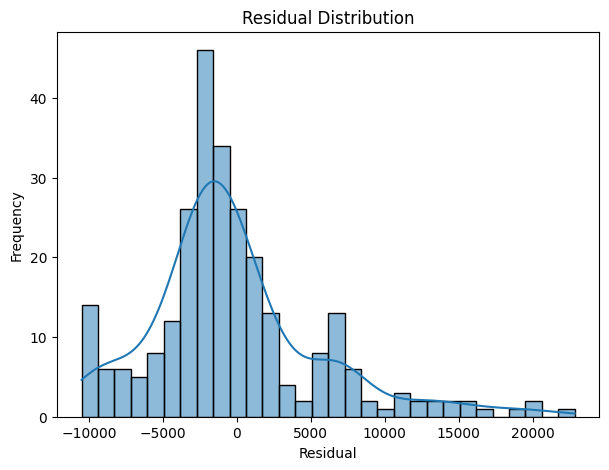

In [64]:
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=30, kde = True) 
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show() 

### **Coefficients Plot**

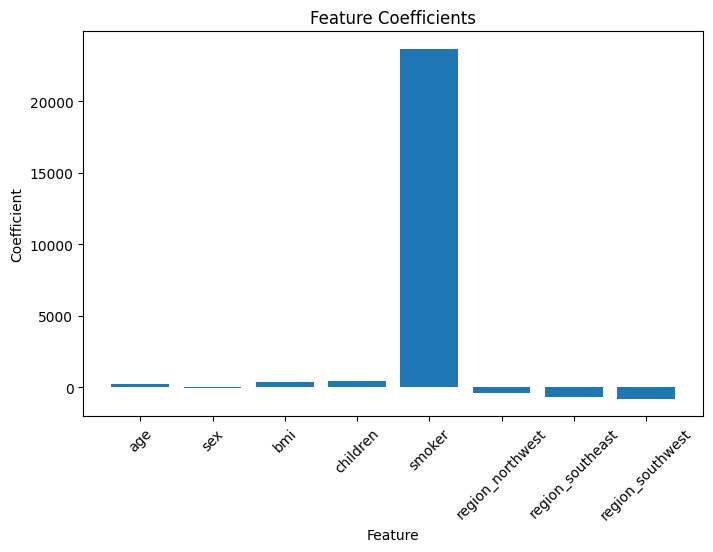

In [65]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

plt.figure(figsize=(8,5))

plt.bar(coef_df["Feature"], coef_df["Coefficient"])

plt.xticks(rotation=45)

plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.title("Feature Coefficients")

plt.show()

In [66]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix) 

                       age       sex       bmi  children    smoker   charges  \
age               1.000000 -0.020856  0.109272  0.042469 -0.025019  0.299008   
sex              -0.020856  1.000000  0.046371  0.017163  0.076185  0.057292   
bmi               0.109272  0.046371  1.000000  0.012759  0.003750  0.198341   
children          0.042469  0.017163  0.012759  1.000000  0.007673  0.067998   
smoker           -0.025019  0.076185  0.003750  0.007673  1.000000  0.787251   
charges           0.299008  0.057292  0.198341  0.067998  0.787251  1.000000   
region_northwest -0.000407 -0.011156 -0.135996  0.024806 -0.036945 -0.039905   
region_southeast -0.011642  0.017117  0.270025 -0.023066  0.068498  0.073982   
region_southwest  0.010016 -0.004184 -0.006205  0.021914 -0.036945 -0.043210   

                  region_northwest  region_southeast  region_southwest  
age                      -0.000407         -0.011642          0.010016  
sex                      -0.011156          0.017117 

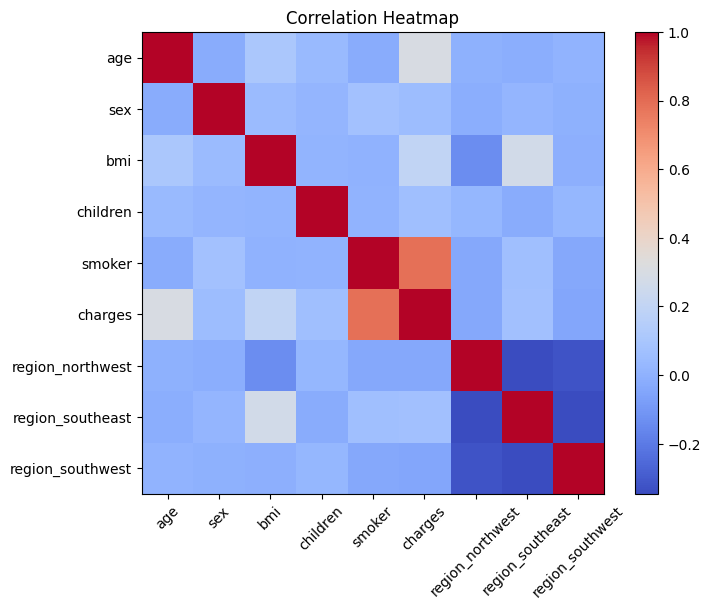

In [67]:
import matplotlib.pyplot as plt

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(corr_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)),
           corr_matrix.columns,
           rotation=45)

plt.yticks(range(len(corr_matrix.columns)),
           corr_matrix.columns)

plt.title("Correlation Heatmap")

plt.show()

## **Variance Inflation Factor (VIF)**

In [68]:
X = X.astype(float)

In [69]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# X should contain only the numerical feature matrix used for modeling
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

            Feature        VIF
0               age   7.686965
1               sex   2.003185
2               bmi  11.358443
3          children   1.809930
4            smoker   1.261233
5  region_northwest   1.890281
6  region_southeast   2.265564
7  region_southwest   1.960745


In [70]:
high_vif = vif_data[vif_data["VIF"] > 5]
print(high_vif) 

  Feature        VIF
0     age   7.686965
2     bmi  11.358443


In [71]:
df["Age_BMI"] = df["age"] * df["bmi"]

In [72]:
df["BMI_squared"] = df["bmi"] ** 2

In [73]:
df["log_charges"] = np.log(df["charges"])

In [74]:
df.head(2)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,Age_BMI,BMI_squared,log_charges
0,19,0,27.90,0,1,16884.9240,False,False,True,530.10,778.4100,9.734176
1,18,1,33.77,1,0,1725.5523,False,True,False,607.86,1140.4129,7.453302


In [75]:
X = df.drop(columns = ["charges", 'log_charges'])

In [76]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()

selector = RFE(model, n_features_to_select=5)

selector.fit(X, y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",5
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
X.head(1)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,Age_BMI,BMI_squared
0,19,0,27.9,0,1,False,False,True,530.1,778.41


In [78]:
selector.support_

array([False, False,  True,  True,  True, False,  True,  True, False,
       False])

## **Polynomial Regression**

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [80]:
from sklearn.preprocessing import PolynomialFeatures 
poly = PolynomialFeatures(degree = 2, include_bias = False) 
X_train_poly = poly.fit_transform(X_train) 
X_test_poly = poly.transform(X_test)

from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(X_train_poly, y_train)

train_pred = model.predict(X_train_poly)
test_pred = model.predict(X_test_poly) 

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Degree 2")
print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, test_pred))

Degree 2
Train R²: 0.8457545235050079
Test R² : 0.8677928996203379


## **Ridge Regression (L2 Regularization)**

In [82]:
from sklearn.linear_model import Ridge
model = Ridge(alpha = 1.0)
model.fit(X_train, y_train)
X_train_pred = model.predict(X_train)
X_test_pred = model.predict(X_test)

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Ridge Regression")
print("Train R²:", r2_score(y_train, X_train_pred))
print("Test R² :", r2_score(y_test, X_test_pred))

Ridge Regression
Train R²: 0.7438171102913211
Test R² : 0.7781337178604354


## **Lasso Regression (L1 Regularization)**

In [84]:
from sklearn.linear_model import Lasso
model = Lasso(alpha=1.0)
model.fit(X_train, y_train)
X_train_pred = model.predict(X_train)
X_test_pred = model.predict(X_test)

In [85]:
print(model.coef_)

[ 2.69316003e+02  1.60991224e+00  1.05786378e+03  4.21443000e+02
  2.36582086e+04 -4.82938771e+02 -5.95644578e+02 -8.45761445e+02
 -4.87168625e-01 -1.12091903e+01]


In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Lasso Regression")
print("Train R²:", r2_score(y_train, X_train_pred))
print("Test R² :", r2_score(y_test, X_test_pred))

Lasso Regression
Train R²: 0.7438375495934513
Test R² : 0.7784204287657455


## **Elastic Net Regression**

In [87]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5
)

model.fit(X_train, y_train)

X_train_pred = model.predict(X_train)
X_test_pred = model.predict(X_test)

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Elastic Net Regression")
print("Train R²:", r2_score(y_train, X_train_pred))
print("Test R² :", r2_score(y_test, X_test_pred))

Elastic Net Regression
Train R²: 0.38389982469291406
Test R² : 0.4172751157271276


## **Hyperparameter Tuning**

### **Grid Search CV**

In [89]:
from sklearn.model_selection import GridSearchCV 
from sklearn.linear_model import Ridge

model = Ridge()

param_grid = {
    'alpha' : [0.01, 0.1, 1, 10, 100]
} 

grid =  GridSearchCV(estimator = model, param_grid = param_grid, cv = 5, scoring = 'r2')

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also d

In [90]:
print(grid.best_params_)

{'alpha': 1}


In [91]:
print(grid.best_score_)

0.7347853990160587


In [92]:
best_model = grid.best_estimator_

In [93]:
best_model

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [94]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge

model = Ridge()

param_dist = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=4,
    cv=5,
    scoring="r2",
    random_state=42
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': [0.001, 0.01, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbos

In [95]:
random_search.best_params_

{'alpha': 0.1}

In [96]:
random_search.best_score_

np.float64(0.7347477943373326)

## **Pipeline**

In [97]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [98]:
X = df.drop("charges", axis=1)

y = df["charges"]

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [100]:
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler  

preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), ['age', 'bmi', 'children']), 
        ("cat", OneHotEncoder(handle_unknown = "ignore"), ['sex', 'smoker', 'region'])
    ]
)

In [101]:
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import Ridge 

In [102]:
pipeline = Pipeline([
    ("preprocesing" , preprocessor), 
    ("model", Ridge(alpha = 1))
])

pipeline.fit(X_train, y_train) 
predictions = pipeline.predict(X_test)

In [103]:
from sklearn.model_selection import GridSearchCV

params = {
    "model__alpha": [0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipeline,
    param_grid=params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ge(alpha=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate p

## **Save Model**

In [104]:
import joblib  
joblib.dump(pipeline, 'insurance_pipeline.pkl')

['insurance_pipeline.pkl']

In [105]:
print(X_train.head())
print(X_train.dtypes)

      age     sex    bmi  children smoker     region
560    46  female  19.95         2     no  northwest
1285   47  female  24.32         0     no  northeast
1142   52  female  24.86         0     no  southeast
969    39  female  34.32         5     no  southeast
486    54  female  21.47         3     no  northwest
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
dtype: object


In [108]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df.drop("charges", axis=1), drop_first=True)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [109]:
from sklearn.tree import DecisionTreeRegressor 

model = DecisionTreeRegressor(max_depth = 4, min_samples_leaf = 5, random_state = 42) 

model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [110]:
predictions = model.predict(X_test)

In [111]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

In [112]:
print("Descision Tree Regression")
print("MAE: ", mae)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

Descision Tree Regression
MAE:  2697.76543053848
RMSE:  21093484.004597444
R2 Score:  0.8641310379678357


In [113]:
X_train_pred = model.predict(X_train)
X_test_pred = model.predict(X_test)

In [114]:
from sklearn.metrics import r2_score
print("Descision Tree Regression")
print("Train R²:", r2_score(y_train, X_train_pred))
print("Test R² :", r2_score(y_test, X_test_pred))

Descision Tree Regression
Train R²: 0.8653110840097293
Test R² : 0.8641310379678357


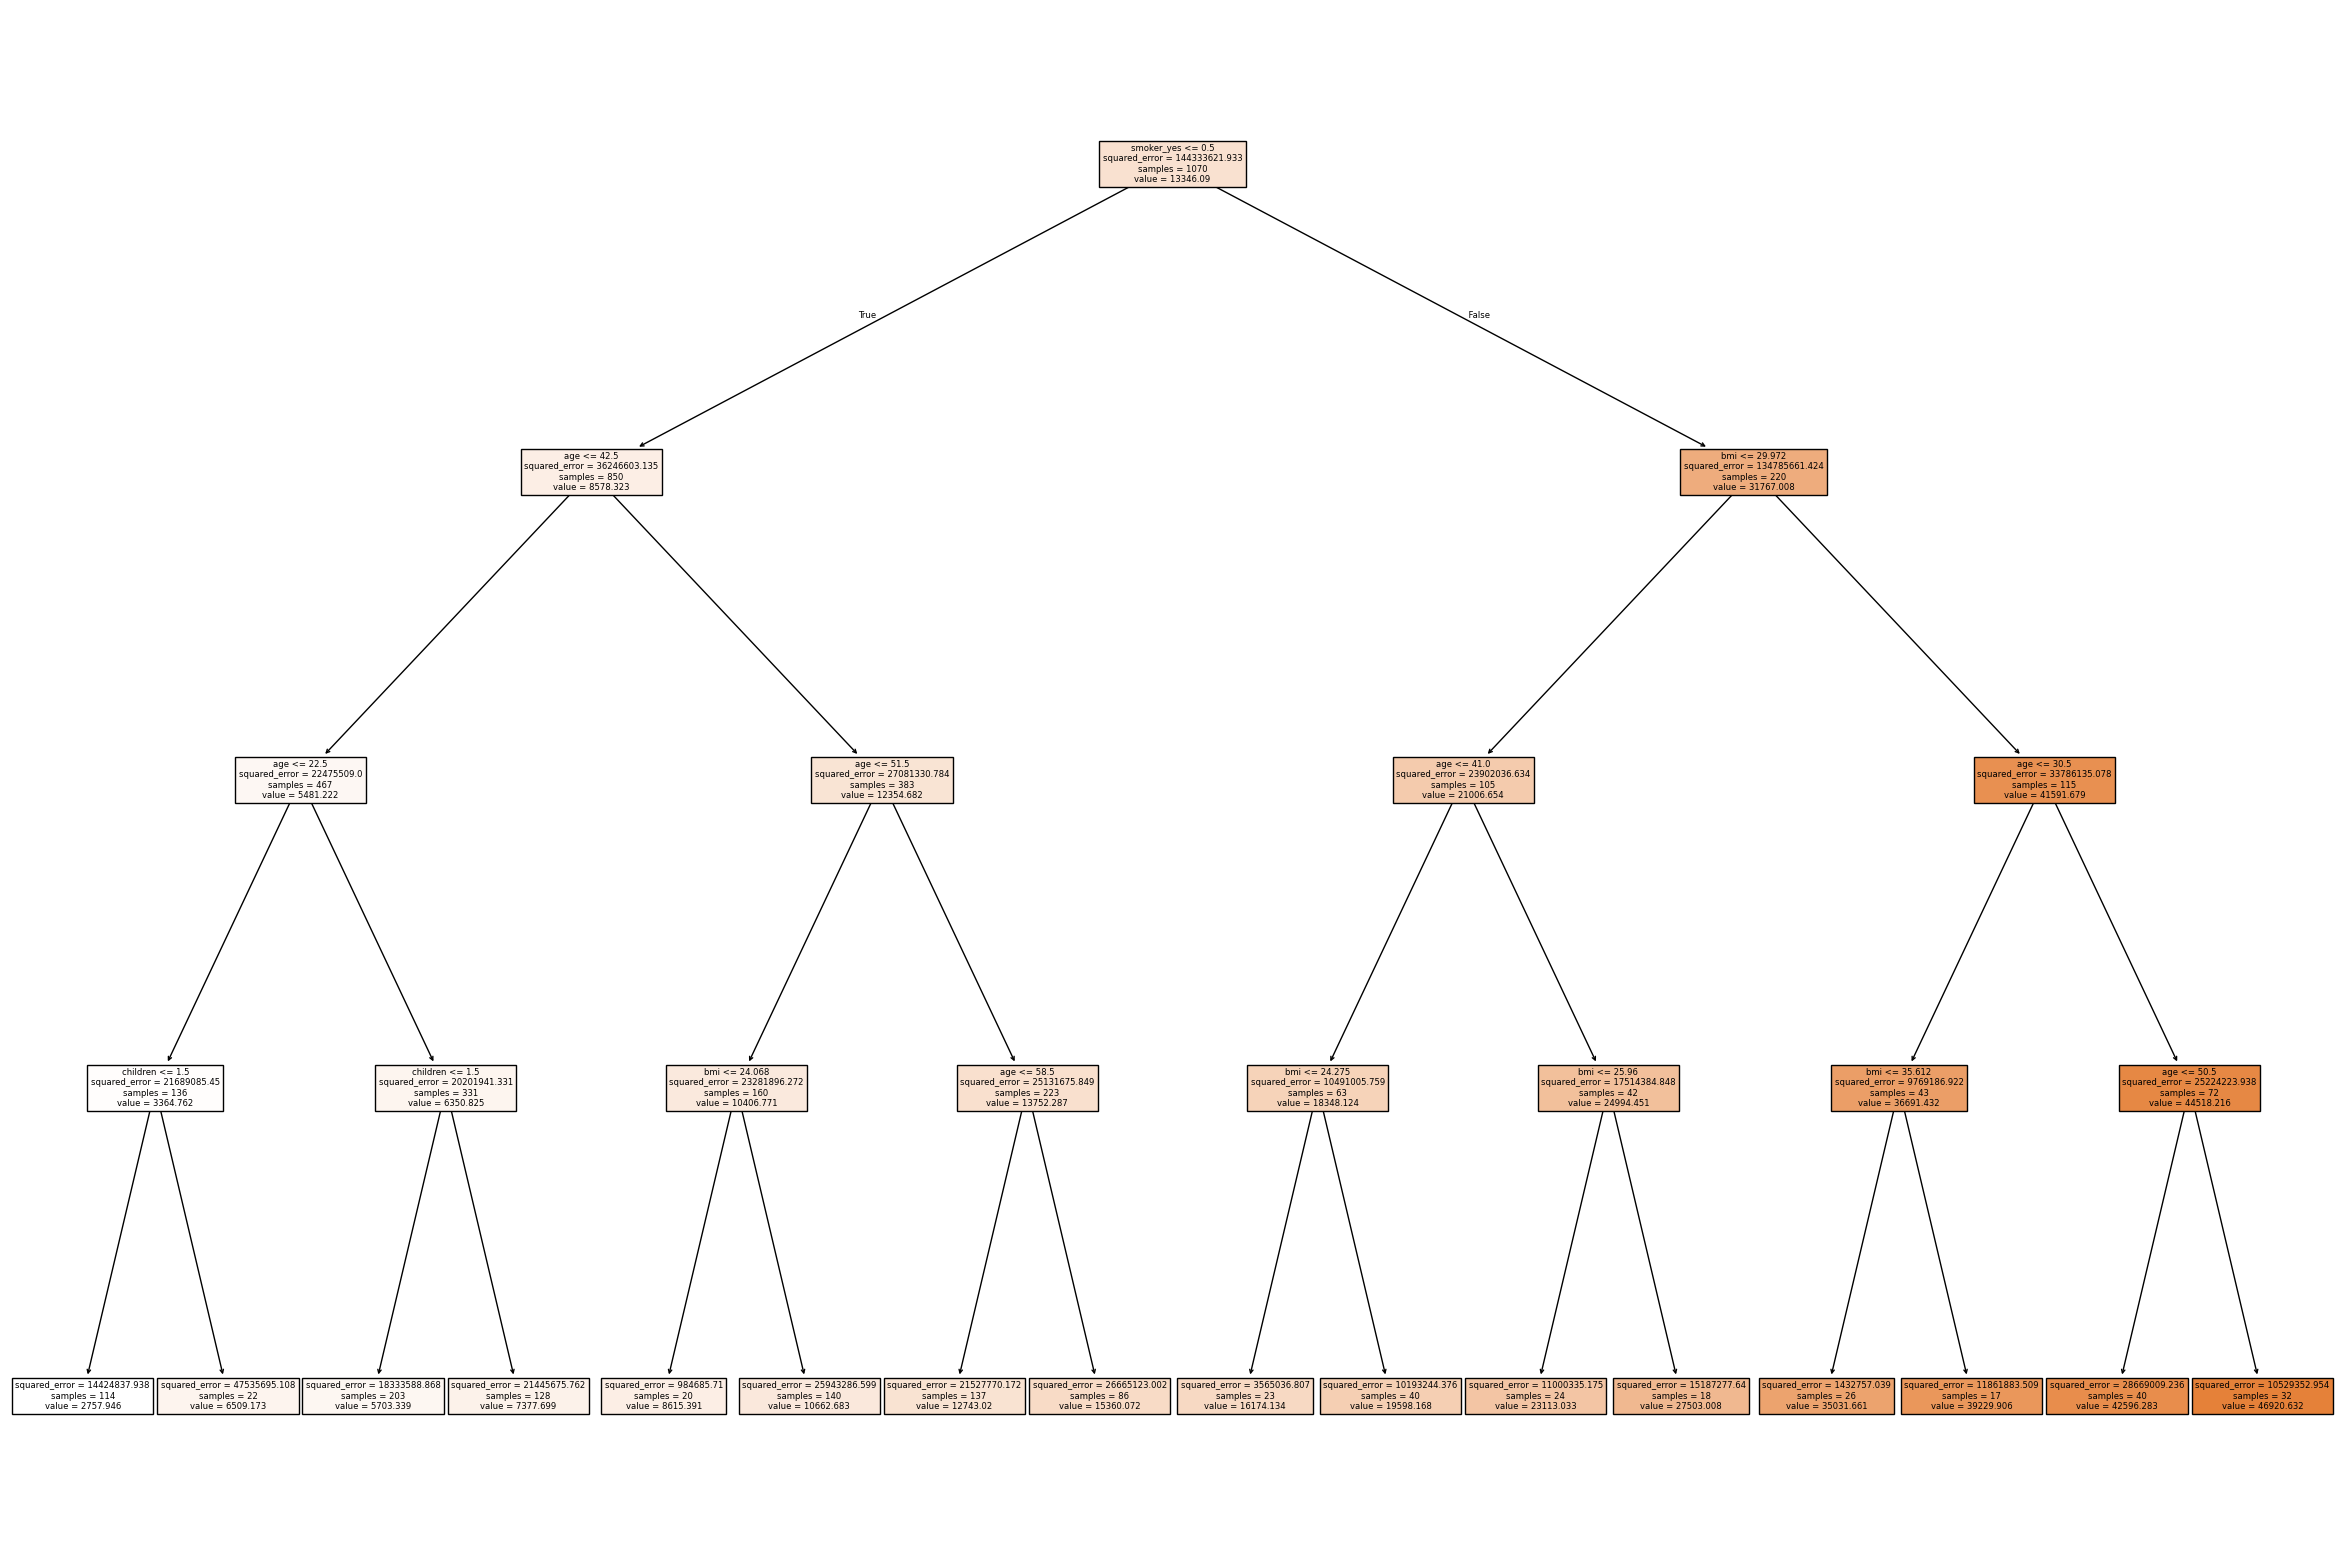

In [115]:
from sklearn.tree import plot_tree 
import matplotlib.pyplot as plt 

plt.figure(figsize = (30, 20))
plot_tree(model, filled = True, feature_names = X.columns) 
plt.show()

In [116]:
importance = model.feature_importances_

In [117]:
print(importance)

[0.11449198 0.1787069  0.00358868 0.         0.70321245 0.
 0.         0.        ]
